# Bitcoin Data Exploration - Price Stradamus

**Purpose**: Understand BTC/USDT 1-minute data patterns to inform model selection

**Contents**:
1. Data Loading & Basic Statistics
2. Price Distributions & Outliers
3. Seasonality & Trends
4. Volume Analysis
5. Feature Correlations
6. Key Insights & Recommendations

**Expected Runtime**: ~2-3 minutes

**Prerequisites**: 
- PostgreSQL database running
- At least 30 days of 1-minute OHLCV data fetched

---

**Feature Engineering Note**: This notebook uses `StatefulFeatureEngineer` for consistency
with the training pipeline. For exploration (no train/test split), we simply call 
`fit_transform()` on the entire dataset.

In [1]:
"""Import libraries and configure visualization settings."""
from __future__ import annotations

import asyncio
from datetime import datetime, timedelta, date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from loguru import logger

from price_stradamus.config.settings import settings
from price_stradamus.data.database import DatabaseManager
# Use StatefulFeatureEngineer for ALL feature generation (including exploration)
from price_stradamus.data.stateful_features import StatefulFeatureEngineer
from price_stradamus.data.preprocessor import DataPreprocessor

# Configure visualization
plt.style.use('dark_background')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

# Matplotlib settings for Jupyter
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

logger.info("Imports complete - Ready for exploration")

2025-12-11 21:14:45.350 | INFO     | __main__:<module>:30 - Imports complete - Ready for exploration


In [2]:
"""Load Bitcoin OHLCV data from PostgreSQL."""

# Load data
db = DatabaseManager(settings.database_url)
await db.initialize()

end_date = datetime.now()
start_date =  date(2025, 8, 1)

df = await db.get_ohlcv(
    symbol="BTCUSDT",
    timeframe="1m",
    start_date=start_date,
    end_date=end_date,
)

await db.close()

# Show data range
df["timestamp"] = pd.to_datetime(df["timestamp"])
data_start = df["timestamp"].min()
data_end = df["timestamp"].max()

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {data_start} to {data_end}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

df.head()

2025-12-11 21:14:45.368 | INFO     | price_stradamus.data.database:__init__:57 - DatabaseManager initialized
2025-12-11 21:14:45.499 | INFO     | price_stradamus.data.database:initialize:82 - Database engine and session maker initialized (pool_size=10, max_overflow=20)
2025-12-11 21:14:45.500 | DEBUG    | price_stradamus.data.database:get_ohlcv:196 - Querying OHLCV data for BTCUSDT 1m
2025-12-11 21:14:49.822 | INFO     | price_stradamus.data.database:get_ohlcv:251 - Retrieved 185146 OHLCV records for BTCUSDT 1m
2025-12-11 21:14:49.881 | INFO     | price_stradamus.data.database:close:92 - Database connections closed


Dataset Shape: (185146, 8)
Date Range: 2025-08-01 00:00:00+00:00 to 2025-12-07 13:45:00+00:00
Memory Usage: 11.30 MB


,timestamp,open,high,low,close,volume,quote_volume,num_trades
0,2025-08-01 00:00:00+00:00,115764.07,115764.08,115704.78,115729.00,11.88,1.37e+06,1421
1,2025-08-01 00:01:00+00:00,115729.00,115747.81,115714.37,115738.75,7.53,8.71e+05,1184
2,2025-08-01 00:02:00+00:00,115738.75,115747.80,115678.75,115706.01,16.24,1.88e+06,1957
3,2025-08-01 00:03:00+00:00,115706.01,115789.04,115706.00,115789.04,14.90,1.72e+06,1667
4,2025-08-01 00:04:00+00:00,115789.04,115803.41,115740.40,115775.93,8.48,9.82e+05,1414


## 1. Basic Statistics & Data Quality

Understanding the fundamental properties of our Bitcoin price data.

In [3]:
"""Validate data quality and display summary statistics."""

# Check for missing values
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

print("Missing Values:")
if missing_pct.sum() == 0:
    print("  ✓ No missing values detected")
else:
    print(missing_pct[missing_pct > 0])

# Basic statistics
print("\n" + "="*60)
print("OHLCV Summary Statistics:")
print("="*60)
print(df[['open', 'high', 'low', 'close', 'volume']].describe())

# Check for duplicates
duplicates = df.duplicated(subset=['timestamp']).sum()
print(f"\nDuplicate timestamps: {duplicates}")

# Check timestamp continuity (1-minute data)
df_sorted = df.sort_values('timestamp')
time_diffs = df_sorted['timestamp'].diff()
expected_freq = pd.Timedelta('1min')
gaps = time_diffs[time_diffs > expected_freq * 1.5]

print(f"\nTime gaps (>1.5min): {len(gaps)}")
if len(gaps) > 0:
    print("First 5 gaps:")
    print(gaps.head())

Missing Values:
  ✓ No missing values detected

OHLCV Summary Statistics:
            open       high        low      close     volume
count  185146.00  185146.00  185146.00  185146.00  185146.00
mean   108752.06  108781.22  108722.71  108751.91      13.45
std      9954.39    9949.17    9959.56    9954.48      25.28
min     80730.67   80956.97   80600.00   80730.66       0.07
25%    105173.14  105210.35  105129.58  105172.62       3.42
50%    111491.74  111518.09  111463.61  111491.68       7.03
75%    115299.56  115320.00  115279.80  115299.55      14.54
max    126114.50  126199.63  126071.86  126114.50    2001.28

Duplicate timestamps: 0

Time gaps (>1.5min): 0


## 2. Price Distributions & Outliers

Analyzing price distribution to identify outliers and understand volatility patterns.

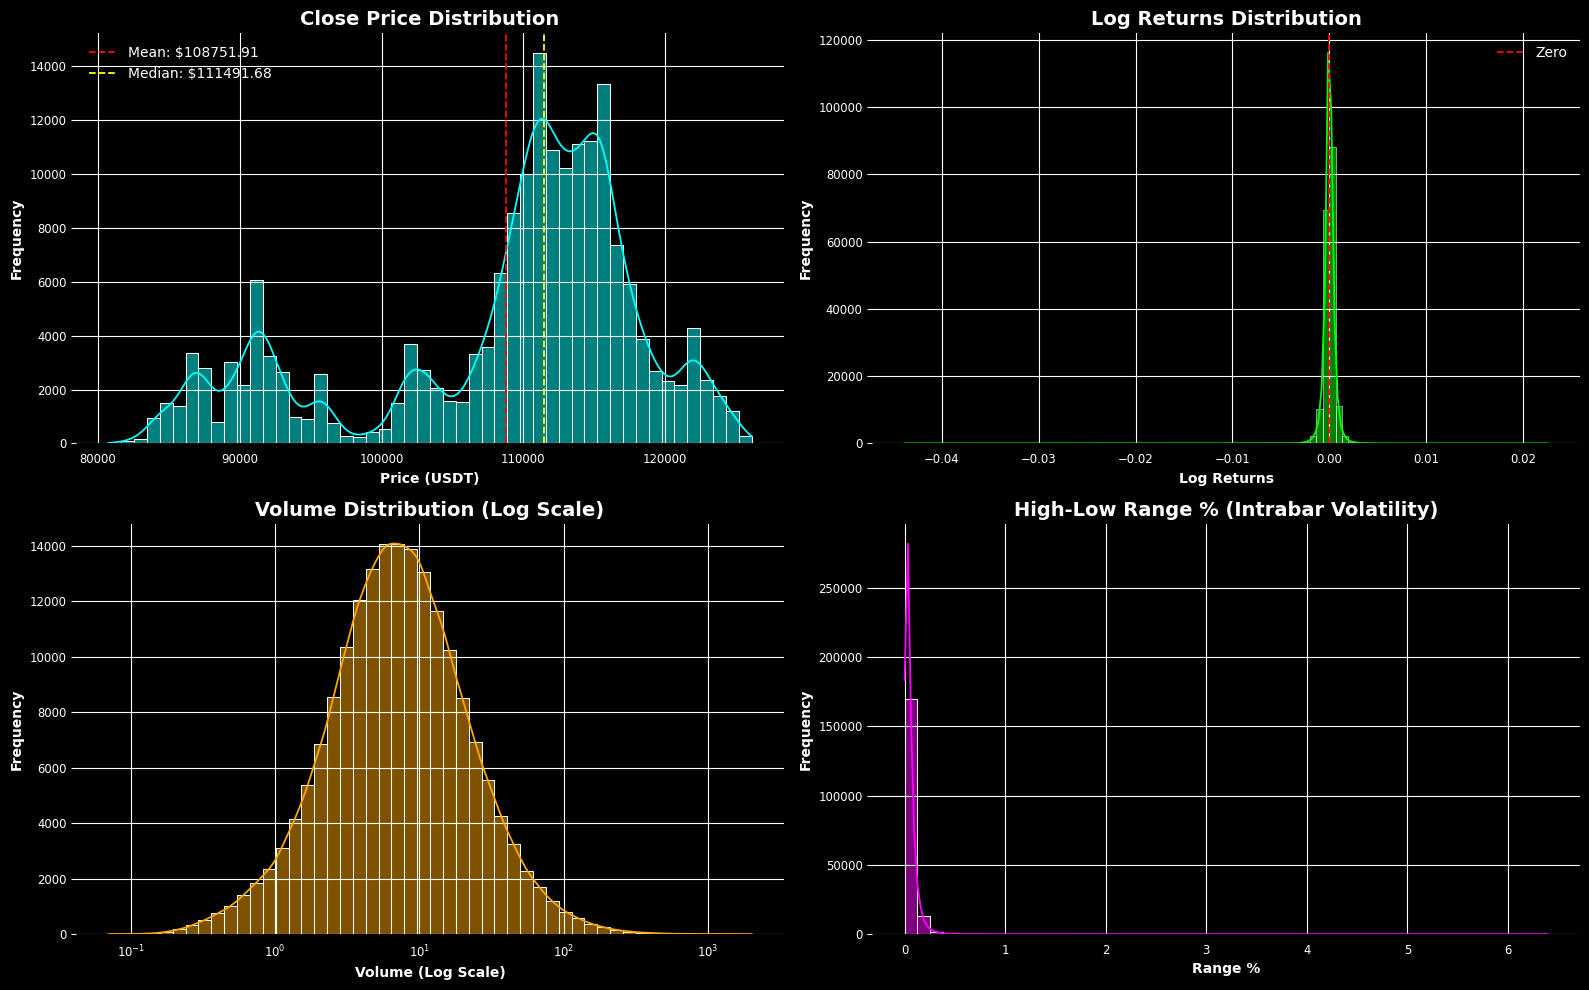

Log Returns - Mean: -0.000001, Std: 0.000579
Log Returns - Skewness: -2.4237, Kurtosis: 224.8756

Interpretation:
  - Kurtosis > 3: Fat tails (more extreme events than normal distribution)
  - Skewness ≈ 0: Symmetric distribution


In [4]:
"""Visualize price distributions and identify outliers."""

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Close price distribution
ax1 = axes[0, 0]
sns.histplot(df['close'], bins=50, kde=True, ax=ax1, color='cyan')
ax1.set_title('Close Price Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Price (USDT)')
ax1.set_ylabel('Frequency')
ax1.axvline(df['close'].mean(), color='red', linestyle='--', label=f'Mean: ${df["close"].mean():.2f}')
ax1.axvline(df['close'].median(), color='yellow', linestyle='--', label=f'Median: ${df["close"].median():.2f}')
ax1.legend()

# Log returns distribution (check for normality)
log_returns = np.log(df['close'] / df['close'].shift(1)).dropna()
ax2 = axes[0, 1]
sns.histplot(log_returns, bins=100, kde=True, ax=ax2, color='lime')
ax2.set_title('Log Returns Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Log Returns')
ax2.set_ylabel('Frequency')
ax2.axvline(0, color='red', linestyle='--', label='Zero')
ax2.legend()

# Volume distribution (log scale due to skew)
ax3 = axes[1, 0]
sns.histplot(df['volume'], bins=50, kde=True, log_scale=(True, False), ax=ax3, color='orange')
ax3.set_title('Volume Distribution (Log Scale)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Volume (Log Scale)')
ax3.set_ylabel('Frequency')

# High-Low range (volatility proxy)
df['hl_range_pct'] = ((df['high'] - df['low']) / df['close']) * 100
ax4 = axes[1, 1]
sns.histplot(df['hl_range_pct'], bins=50, kde=True, ax=ax4, color='magenta')
ax4.set_title('High-Low Range % (Intrabar Volatility)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Range %')
ax4.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print outlier statistics
print(f"Log Returns - Mean: {log_returns.mean():.6f}, Std: {log_returns.std():.6f}")
print(f"Log Returns - Skewness: {log_returns.skew():.4f}, Kurtosis: {log_returns.kurtosis():.4f}")
print(f"\nInterpretation:")
print(f"  - Kurtosis > 3: Fat tails (more extreme events than normal distribution)")
print(f"  - Skewness ≈ 0: Symmetric distribution")

## 3. Temporal Patterns - Seasonality & Trends

Identifying hourly, daily, and weekly patterns that may inform feature engineering.

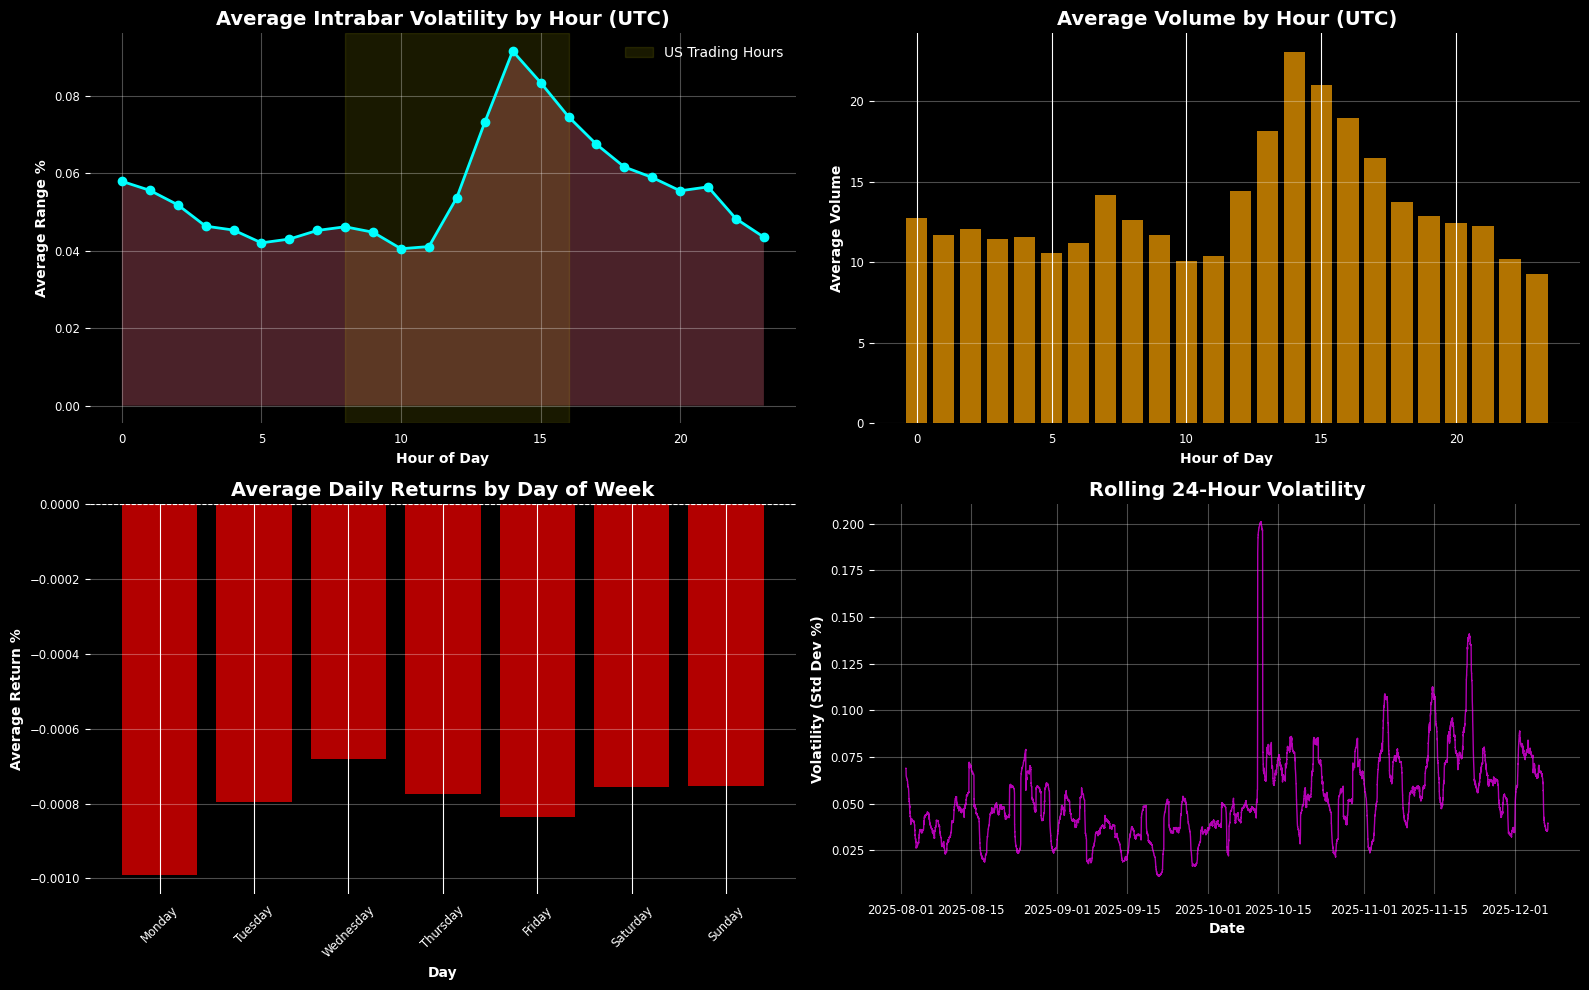

Key Observations:
  - Highest volatility hour: 14:00 UTC (0.092%)
  - Lowest volatility hour: 10:00 UTC (0.040%)
  - Highest volume hour: 14:00 UTC
  - Best performing day: Wednesday (+-0.001%)


In [5]:
"""Analyze temporal patterns and seasonality."""

# Extract time features
df_temporal = df.copy()
df_temporal['hour'] = df_temporal['timestamp'].dt.hour
df_temporal['day_of_week'] = df_temporal['timestamp'].dt.dayofweek
df_temporal['day_name'] = df_temporal['timestamp'].dt.day_name()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Hourly volatility pattern
hourly_volatility = df_temporal.groupby('hour')['hl_range_pct'].mean()
ax1 = axes[0, 0]
ax1.plot(hourly_volatility.index, hourly_volatility.values, marker='o', linewidth=2, color='cyan')
ax1.fill_between(hourly_volatility.index, hourly_volatility.values, alpha=0.3)
ax1.set_title('Average Intrabar Volatility by Hour (UTC)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Average Range %')
ax1.grid(True, alpha=0.3)
ax1.axvspan(8, 16, alpha=0.1, color='yellow', label='US Trading Hours')
ax1.legend()

# Hourly volume pattern
hourly_volume = df_temporal.groupby('hour')['volume'].mean()
ax2 = axes[0, 1]
ax2.bar(hourly_volume.index, hourly_volume.values, color='orange', alpha=0.7)
ax2.set_title('Average Volume by Hour (UTC)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Average Volume')
ax2.grid(True, alpha=0.3, axis='y')

# Day of week patterns
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_returns = df_temporal.groupby('day_name')['close'].apply(lambda x: x.pct_change().mean() * 100)
daily_returns = daily_returns.reindex(day_order)
ax3 = axes[1, 0]
colors_daily = ['green' if x > 0 else 'red' for x in daily_returns.values]
ax3.bar(range(len(daily_returns)), daily_returns.values, color=colors_daily, alpha=0.7)
ax3.set_title('Average Daily Returns by Day of Week', fontsize=14, fontweight='bold')
ax3.set_xlabel('Day')
ax3.set_ylabel('Average Return %')
ax3.set_xticks(range(len(day_order)))
ax3.set_xticklabels(day_order, rotation=45)
ax3.axhline(0, color='white', linestyle='--', linewidth=0.8)
ax3.grid(True, alpha=0.3, axis='y')

# Rolling volatility (24-hour window)
df_temporal['rolling_vol'] = df_temporal['close'].pct_change().rolling(window=24*60).std() * 100
ax4 = axes[1, 1]
ax4.plot(df_temporal['timestamp'], df_temporal['rolling_vol'], linewidth=1, color='magenta', alpha=0.7)
ax4.set_title('Rolling 24-Hour Volatility', fontsize=14, fontweight='bold')
ax4.set_xlabel('Date')
ax4.set_ylabel('Volatility (Std Dev %)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Observations:")
print(f"  - Highest volatility hour: {hourly_volatility.idxmax()}:00 UTC ({hourly_volatility.max():.3f}%)")
print(f"  - Lowest volatility hour: {hourly_volatility.idxmin()}:00 UTC ({hourly_volatility.min():.3f}%)")
print(f"  - Highest volume hour: {hourly_volume.idxmax()}:00 UTC")
print(f"  - Best performing day: {daily_returns.idxmax()} (+{daily_returns.max():.3f}%)")

## 4. Feature Engineering & Correlations

Generate technical indicators and analyze relationships with future prices.

Using `StatefulFeatureEngineer.fit_transform()` on the entire dataset for exploration.

In [6]:
"""Generate all technical indicators using StatefulFeatureEngineer.

For exploration (no train/test split), we use fit_transform() on the entire dataset.
This is the same class used in training, ensuring consistency.
"""
from price_stradamus.config.constants import FEATURE_WARMUP_PERIOD

# Preprocess data
preprocessor = DataPreprocessor()
df_clean = preprocessor.validate_ohlcv(df)
df_clean = preprocessor.handle_missing_values(df_clean)

# Generate features using StatefulFeatureEngineer
# For exploration, fit_transform on entire dataset is fine
engineer = StatefulFeatureEngineer(warmup_period=FEATURE_WARMUP_PERIOD)
df_features = engineer.fit_transform(df_clean)

print(f"Generated {len(engineer.feature_list)} technical indicators")
print(f"Rows after warmup removal: {len(df_features)} (dropped {len(df_clean) - len(df_features)} warmup rows)")

print(f"\nFeature categories:")
print(f"  - Price features: returns, log_returns, price_change, ranges")
print(f"  - Moving averages: SMA (7,14,30,50,200), EMA (7,14,30,50,200)")
print(f"  - Momentum: RSI, MACD, Stochastic, ROC, CCI, Williams %R")
print(f"  - Volatility: ATR, Bollinger Bands, Std Dev")
print(f"  - Volume: OBV, Volume SMA, Volume ratios")
print(f"  - Trend: ADX, Aroon, Supertrend")

# Check for any remaining NaN values
nan_counts = df_features[engineer.feature_list].isnull().sum()
features_with_nan = nan_counts[nan_counts > 0]

if len(features_with_nan) > 0:
    print(f"\n⚠️ Features with NaN values:")
    print(features_with_nan)
else:
    print(f"\n✓ No NaN values in features after warmup removal")

# Use df_features directly for correlation analysis (warmup already dropped)
df_features_clean = df_features.dropna(subset=engineer.feature_list)
print(f"\nRows available for correlation analysis: {len(df_features_clean)}")

2025-12-11 21:14:55.769 | INFO     | price_stradamus.data.preprocessor:__init__:60 - DataPreprocessor initialized (normalization=minmax)
2025-12-11 21:14:55.822 | DEBUG    | price_stradamus.data.preprocessor:validate_ohlcv:138 - OHLCV validation passed for 185146 rows
2025-12-11 21:14:55.826 | DEBUG    | price_stradamus.data.preprocessor:handle_missing_values:167 - No missing values found
2025-12-11 21:14:55.826 | INFO     | price_stradamus.data.stateful_features:__init__:133 - StatefulFeatureEngineer initialized (warmup_period=200)
2025-12-11 21:14:55.827 | INFO     | price_stradamus.data.stateful_features:fit:156 - Fitting feature statistics on 185146 training samples


[!] VWAP requires an ordered DatetimeIndex.


2025-12-11 21:15:01.163 | INFO     | price_stradamus.data.stateful_features:fit:195 - Fitted statistics for 60 features
2025-12-11 21:15:01.173 | DEBUG    | price_stradamus.data.stateful_features:transform:227 - Transforming 185146 samples


[!] VWAP requires an ordered DatetimeIndex.
Generated 60 technical indicators
Rows after warmup removal: 184946 (dropped 200 warmup rows)

Feature categories:
  - Price features: returns, log_returns, price_change, ranges
  - Moving averages: SMA (7,14,30,50,200), EMA (7,14,30,50,200)
  - Momentum: RSI, MACD, Stochastic, ROC, CCI, Williams %R
  - Volatility: ATR, Bollinger Bands, Std Dev
  - Volume: OBV, Volume SMA, Volume ratios
  - Trend: ADX, Aroon, Supertrend

⚠️ Features with NaN values:
bb_lower      2
bb_upper      2
bb_width      2
bb_percent    2
dtype: int64

Rows available for correlation analysis: 184944


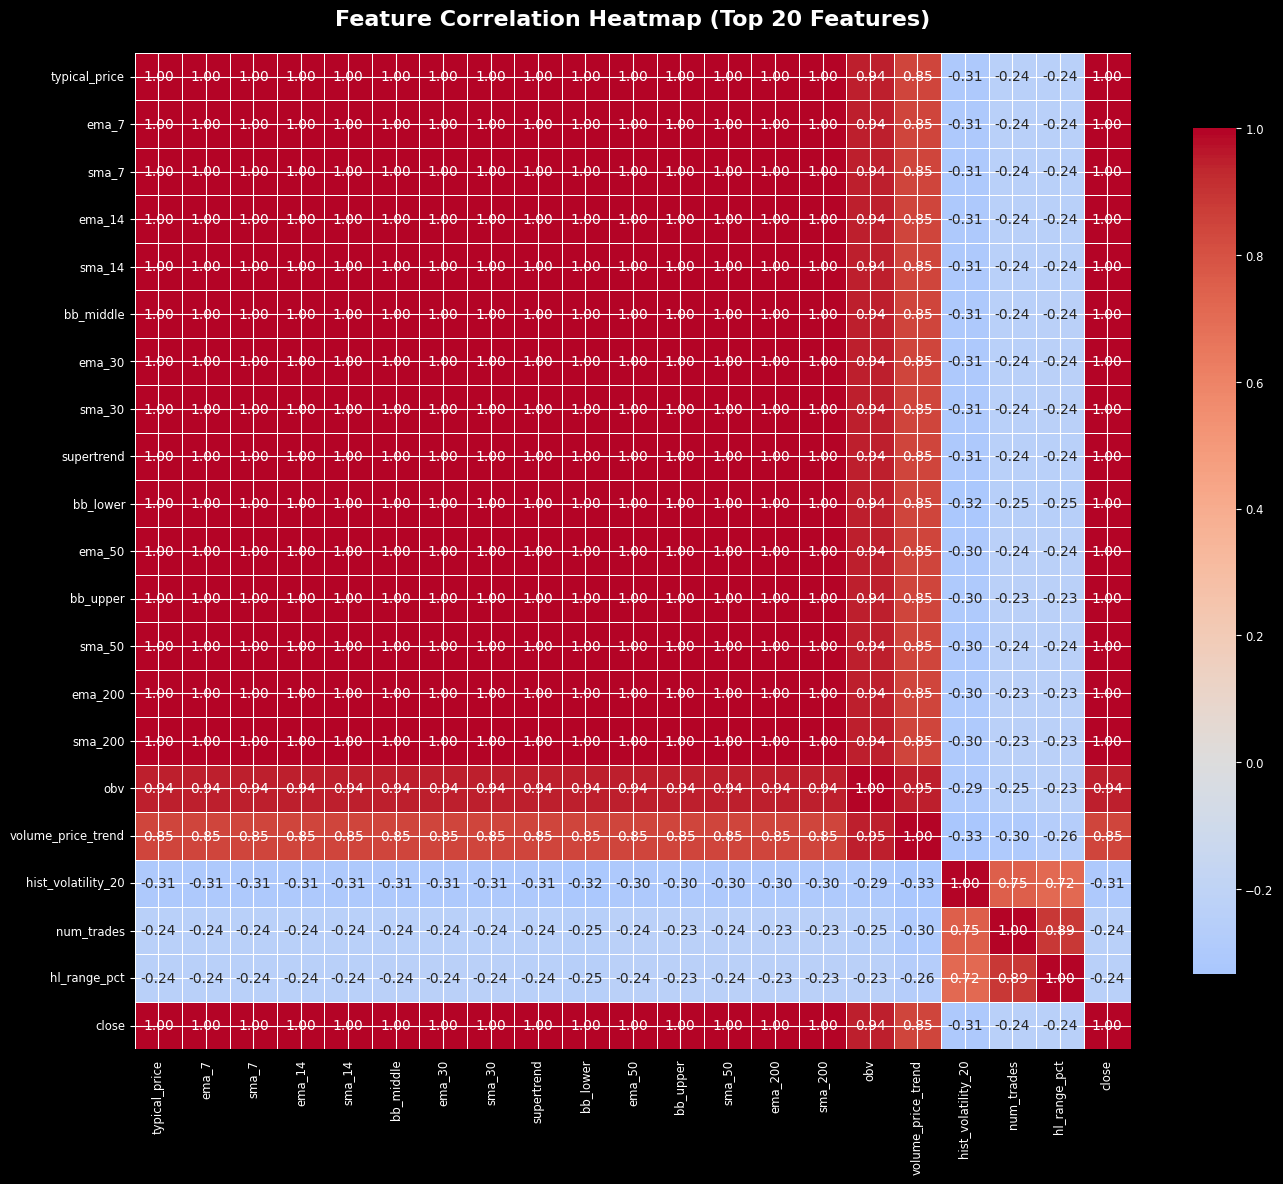

Top 10 features correlated with close price:
typical_price    1.0
ema_7            1.0
sma_7            1.0
ema_14           1.0
sma_14           1.0
bb_middle        1.0
ema_30           1.0
sma_30           1.0
supertrend       1.0
bb_lower         1.0
dtype: float64


In [7]:
"""Visualize feature correlations with target (close price)."""

# Select top 20 features by correlation with close price
correlations = df_features_clean[engineer.feature_list].corrwith(df_features_clean['close']).abs()
top_features = correlations.nlargest(20).index.tolist()

# Create correlation matrix for top features
corr_matrix = df_features_clean[top_features + ['close']].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title('Feature Correlation Heatmap (Top 20 Features)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Top 10 features correlated with close price:")
print(correlations.nlargest(10))

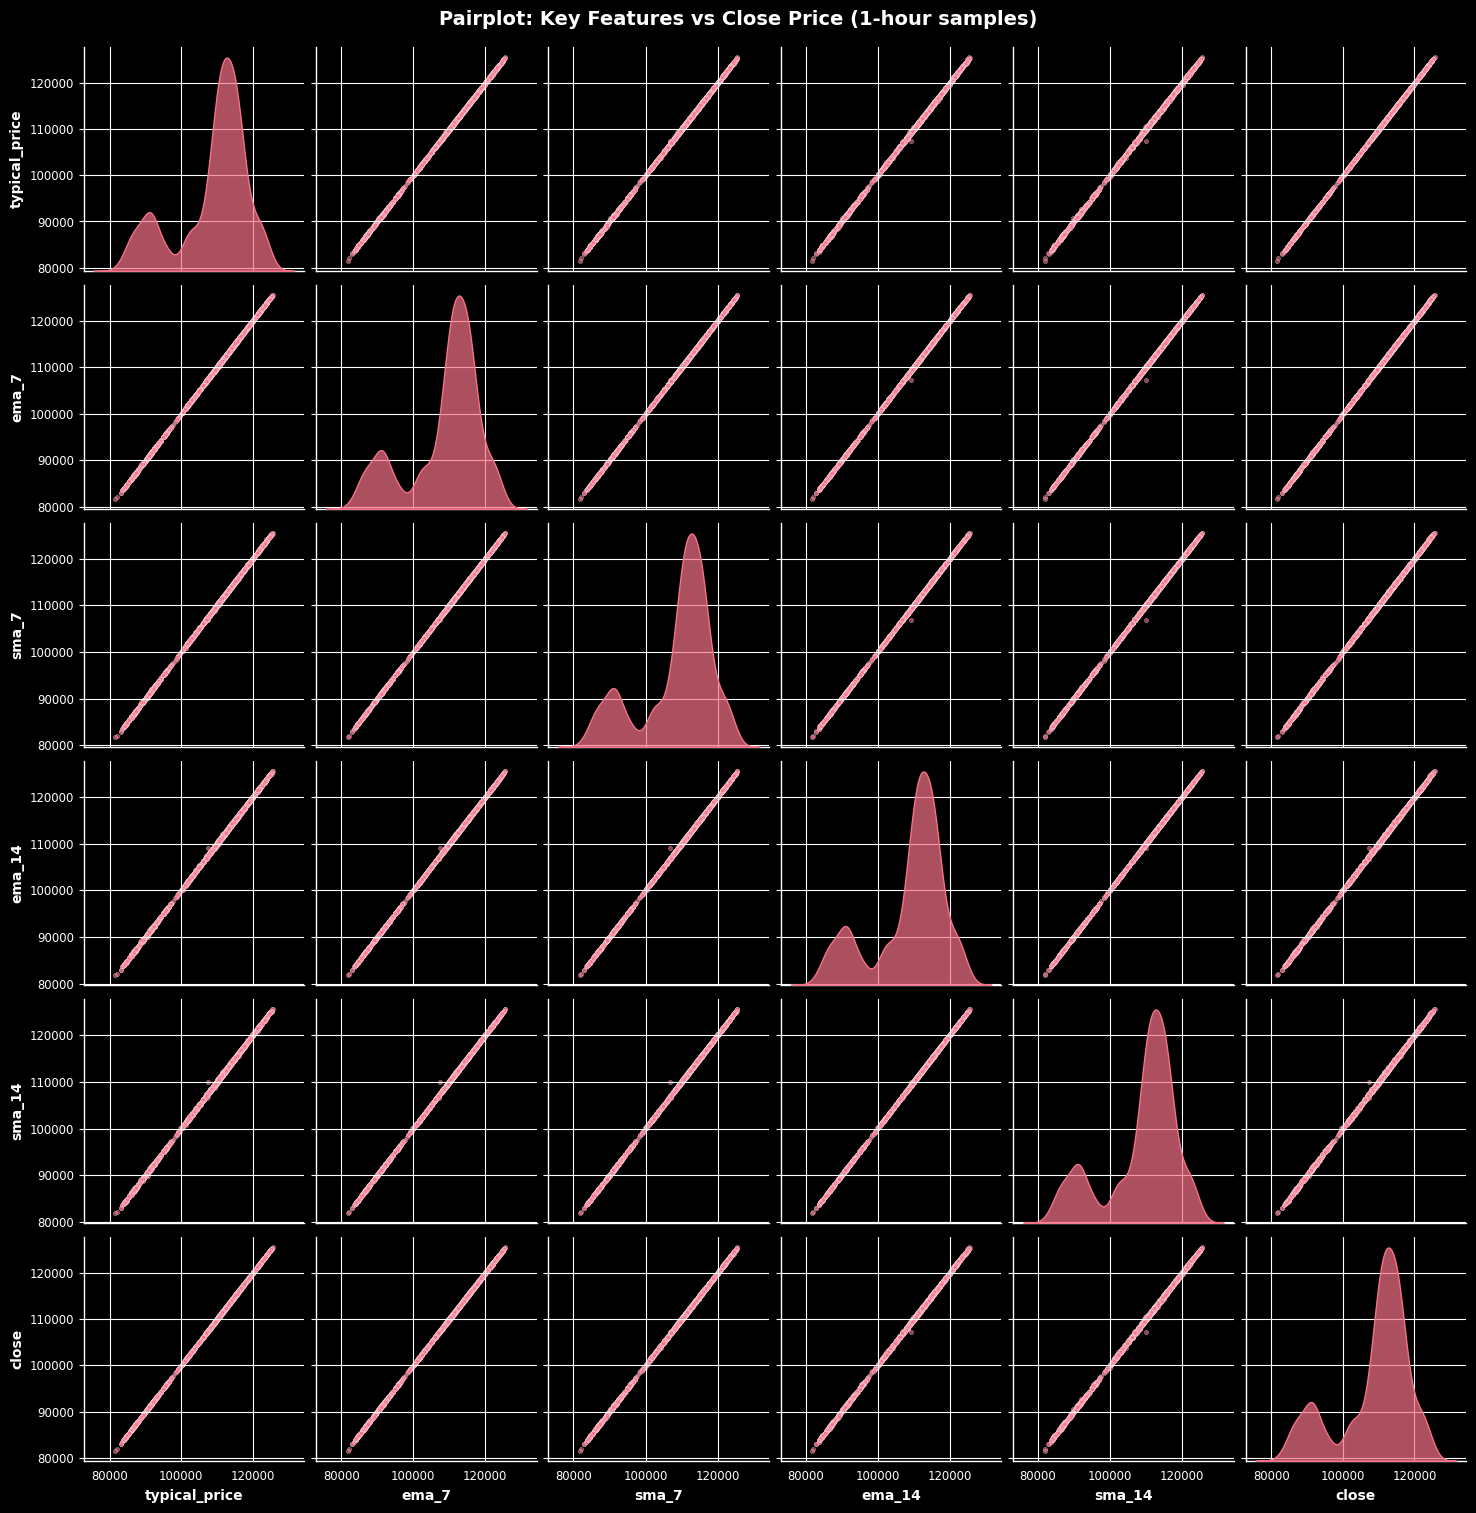

Sampled 3083 points (every 60 minutes) for visualization


In [8]:
"""Visualize relationships between key features."""

# Select 5 most correlated features + close
key_features = correlations.nlargest(5).index.tolist() + ['close']

# Sample data for faster plotting (every 60th row = 1 hour)
df_sample = df_features_clean[key_features].iloc[::60].copy()

# Create pairplot
pairplot = sns.pairplot(
    df_sample,
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 10},
    diag_kws={'alpha': 0.7},
)
pairplot.fig.suptitle('Pairplot: Key Features vs Close Price (1-hour samples)', y=1.01, fontsize=14, fontweight='bold')
plt.show()

print(f"Sampled {len(df_sample)} points (every 60 minutes) for visualization")

## 5. Key Insights & Recommendations

Summary of findings to guide model development.

In [9]:
"""Generate key insights and modeling recommendations."""

print("="*70)
print(" BITCOIN DATA EXPLORATION - KEY INSIGHTS ")
print("="*70)

# Price statistics
price_change = ((df['close'].iloc[-1] - df['close'].iloc[0]) / df['close'].iloc[0]) * 100
print(f"\n1. PRICE STATISTICS ({len(df)//1440} days)")
print(f"   - Price change: {price_change:+.2f}%")
print(f"   - Average close: ${df['close'].mean():.2f}")
print(f"   - Volatility (std): ${df['close'].std():.2f}")
print(f"   - Min/Max: ${df['close'].min():.2f} / ${df['close'].max():.2f}")

# Distribution properties
print(f"\n2. DISTRIBUTION PROPERTIES")
print(f"   - Log returns kurtosis: {log_returns.kurtosis():.2f} (>3 = fat tails)")
print(f"   - Log returns skewness: {log_returns.skew():.2f} (≈0 = symmetric)")
print(f"   - Implication: Expect more extreme price moves than normal distribution")

# Seasonality findings
print(f"\n3. TEMPORAL PATTERNS")
print(f"   - Peak volatility: {hourly_volatility.idxmax()}:00 UTC")
print(f"   - Lowest volatility: {hourly_volatility.idxmin()}:00 UTC")
print(f"   - Best day: {daily_returns.idxmax()} ({daily_returns.max():+.3f}%)")
print(f"   - Implication: Time-of-day features may improve predictions")

# Feature correlations
top_3_features = correlations.nlargest(3)
print(f"\n4. MOST PREDICTIVE FEATURES (correlation with close)")
for feature, corr in top_3_features.items():
    if pd.notna(corr):
        print(f"   - {feature}: {corr:.4f}")
    else:
        print(f"   - {feature}: N/A (insufficient data)")

# Modeling recommendations
print(f"\n5. MODELING RECOMMENDATIONS")
print(f"   ✓ Use 1-minute data (sufficient granularity observed)")
print(f"   ✓ Include time-of-day features (clear hourly patterns)")
print(f"   ✓ Consider volatility regimes (changing rolling volatility)")
print(f"   ✓ Use walk-forward validation (temporal dependence)")
print(f"   ✓ Monitor for extreme events (fat-tailed distribution)")

# Feature engineering reminder
print(f"\n6. FEATURE ENGINEERING FOR MODEL TRAINING")
print(f"   ✓ Use StatefulFeatureEngineer with fit-transform pattern:")
print(f"     engineer = StatefulFeatureEngineer()")
print(f"     train_features = engineer.fit_transform(train_df)  # Fit on train")
print(f"     test_features = engineer.transform(test_df)        # Transform test")
print(f"   See proper_train_test_split.ipynb for correct implementation")

print(f"\n7. NEXT STEPS")
print(f"   → Proceed to model_comparison.ipynb to train 8 models")
print(f"   → Implement walk-forward validation (see backtest_visualization.ipynb)")
print(f"   → Include transaction costs in backtests (0.1% commission + slippage)")

print("="*70)

 BITCOIN DATA EXPLORATION - KEY INSIGHTS 

1. PRICE STATISTICS (128 days)
   - Price change: -23.11%
   - Average close: $108751.91
   - Volatility (std): $9954.48
   - Min/Max: $80730.66 / $126114.50

2. DISTRIBUTION PROPERTIES
   - Log returns kurtosis: 224.88 (>3 = fat tails)
   - Log returns skewness: -2.42 (≈0 = symmetric)
   - Implication: Expect more extreme price moves than normal distribution

3. TEMPORAL PATTERNS
   - Peak volatility: 14:00 UTC
   - Lowest volatility: 10:00 UTC
   - Best day: Wednesday (-0.001%)
   - Implication: Time-of-day features may improve predictions

4. MOST PREDICTIVE FEATURES (correlation with close)
   - typical_price: 1.0000
   - ema_7: 1.0000
   - sma_7: 1.0000

5. MODELING RECOMMENDATIONS
   ✓ Use 1-minute data (sufficient granularity observed)
   ✓ Include time-of-day features (clear hourly patterns)
   ✓ Consider volatility regimes (changing rolling volatility)
   ✓ Use walk-forward validation (temporal dependence)
   ✓ Monitor for extreme eve